Nama : Rayhan Christian Wewengkang | NIM : 2024081005 | WEEK 10


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler

In [8]:
data = {
    'IPK': [3.5, 2.8, 3.2],
    'SKS': [22, 18, 20],
    'Status': [1, 0, 1]
}
df = pd.DataFrame(data)
X = df[['IPK', 'SKS']]
y = df['Status']

In [9]:
# 2. Normalisasi Data (Feature Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# 3. Latih Model Perceptron
model = Perceptron(max_iter=1000, random_state=42)
model.fit(X_scaled, y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",42


In [11]:
# 4. Ambil Parameter Model (Bobot dan Bias)
w1 = model.coef_[0][0]
w2 = model.coef_[0][1]
b = model.intercept_[0]

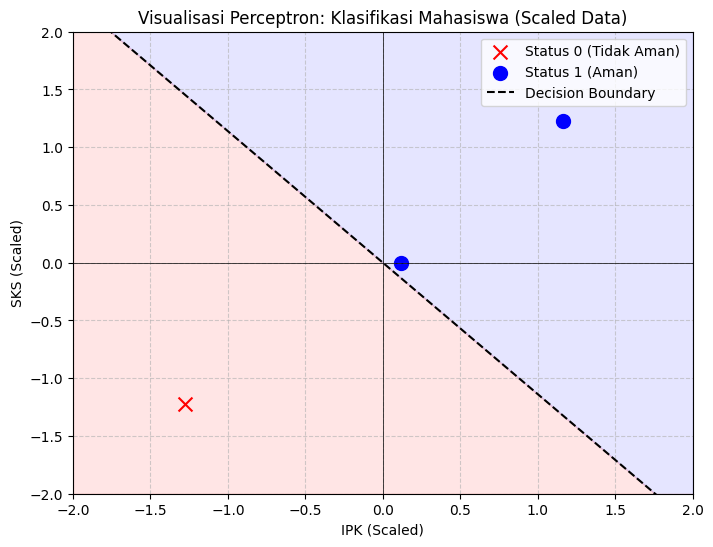

In [12]:
# 5. Visualisasi Decision Boundary
plt.figure(figsize=(8, 6))

# Plot titik data berdasarkan kelas
plt.scatter(X_scaled[y == 0][:, 0], X_scaled[y == 0][:, 1], color='red', marker='x', s=100, label='Status 0 (Tidak Aman)')
plt.scatter(X_scaled[y == 1][:, 0], X_scaled[y == 1][:, 1], color='blue', marker='o', s=100, label='Status 1 (Aman)')

# Membuat garis decision boundary: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1/w2)*x1 - (b/w2)
x1_range = np.linspace(-2, 2, 100)
x2_boundary = -(w1/w2) * x1_range - (b/w2)

# Plot garis
plt.plot(x1_range, x2_boundary, '--k', label='Decision Boundary')

# Atur area yang diarsir untuk menunjukkan wilayah prediksi
plt.fill_between(x1_range, x2_boundary, 2, color='blue', alpha=0.1)
plt.fill_between(x1_range, -2, x2_boundary, color='red', alpha=0.1)

# Format Grafik
plt.title('Visualisasi Perceptron: Klasifikasi Mahasiswa (Scaled Data)')
plt.xlabel('IPK (Scaled)')
plt.ylabel('SKS (Scaled)')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.show()